In [37]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Lato"

from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
k_max = 12
pars = {
    "eta"   : 0.5, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][1:3] = 1/2
pars["gamma"][0:2] = 1/2

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]

In [39]:
timesteps = int(1e6)
H = hg.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

max_size = 3
# r = np.zeros(shape=(max_size, max_size, max_size))
r = defaultdict(int)
r[(2, 2, 0)] = 1
save_r = []
edge_size_dict = defaultdict(int)
edge_size_dict[2] += 2


In [40]:
for cc in range(timesteps): 
    H.sample_edge(eta, beta, gamma, True)

In [41]:
def intersection_profile(H, update_every = 1):

    timesteps = len(H.edges)
    r = defaultdict(int)
    # r[(2, 2, 0)] = 1
    save_r = []
    edge_size_dict = defaultdict(int)
    # edge_size_dict[2] += 2

    R = np.zeros(shape = (timesteps // update_every + 1, k_max), dtype = int)

    for eid in H.edges:
        e = H.edges.members(eid)
        e_size = len(e)
        de = H.edge_neighborhood(eid, prior_only = True, as_node_sets = True)
        # print(len(de))
        # print(eid, e)
        for nb in de:
            nb_size = len(nb)
            k = len(e.intersection(nb))
            r[(e_size, nb_size, k)] += 1
            # if nb_size != e_size:
            #     r[(nb_size, e_size, k)] += 1
                
        neighbor_sizes = [len(x) for x in de]
        nb_size_cnt = Counter(neighbor_sizes)
        for j, nj in edge_size_dict.items():
            # assert(nj >= nb_size_cnt[j])
            r[(j, e_size, 0)] += nj - nb_size_cnt[j]
            # if j != e_size:
            #     r[(e_size, j, 0)] += nj - nb_size_cnt[j]
        
        # print(eid, update_every)
        if eid % update_every == 0:
        # print(cc)
            for k in range(k_max):
                R[eid//update_every, k] = sum([r[(i, j, k)] for i in range(k_max) for j in range(k_max)])
        edge_size_dict[e_size] += 1
    R = R / R.sum(axis = 1)[:, None] 
        
    return r, R
        

In [42]:
r, R = intersection_profile(H)

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_55383/180233017.py:39: RuntimeWarning: invalid value encountered in divide
  R = R / R.sum(axis = 1)[:, None]


IndexError: boolean index did not match indexed array along axis 0; size of axis is 20 but size of corresponding boolean axis is 1000003

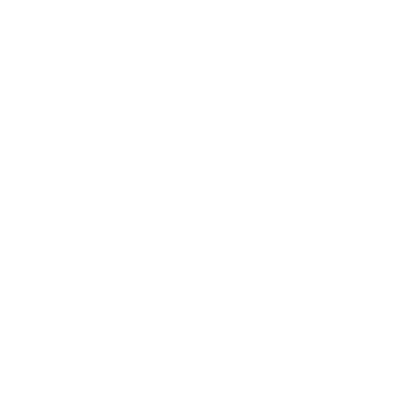

In [ ]:
# arty version of first panel

from scipy.interpolate import make_interp_spline, BSpline



k_min = 0
show_k_up_to = 10
import matplotlib.cm as cm
cmap = cm.twilight_r

fig, ax = plt.subplots(1, 1, figsize = (5, 5))

ax.axis("off")

R_ = R / R.sum(axis = 1)[:, None]
R_[R_ == 0] = np.nan

l = R_.shape[0]

decay = 2

subsample = (decay**np.arange(0, np.log(timesteps)/np.log(decay))).astype(int)



for intersection_size in range(k_min, show_k_up_to): 
    # try: 
    mask = np.isfinite(R_[:, intersection_size])
    
    sub_ = subsample[mask]
    
    spl = make_interp_spline(subsamplep, R_[subsample, intersection_size], k=3)
    # ax.plot(subsample, R_[ subsample, k],  color = cmap(k/(show_k_up_to - k_min+1)), linewidth = 3.5, alpha = 0.8)
    ax.plot(subsample, spl(subsample),  color = cmap(intersection_size/(show_k_up_to - k_min+1)), linewidth = 3.5, alpha = 0.8)
    # except: 
    #     pass

# ax.loglog()

plt.savefig("../fig/intersection-asymptotics-minimal.png", dpi = 1500, bbox_inches = "tight")

In [73]:
# R_[subsample, 1]
mask = np.isfinite(R_[subsample, 1])
R_[subsample,:][mask,1]
subsample[mask]

array([     2,      4,      8,     16,     32,     64,    128,    256,
          512,   1024,   2048,   4096,   8192,  16384,  32768,  65536,
       131072, 262144, 524288])

In [71]:
subsample

array([     1,      2,      4,      8,     16,     32,     64,    128,
          256,    512,   1024,   2048,   4096,   8192,  16384,  32768,
        65536, 131072, 262144, 524288])